# Validación manual de un modelo — Python

Replica la notebook R: mismo dataset, orden de filas, columnas, benchmark, selección del mejor modelo, ajuste de parámetros, meses, curva y registro histórico.

Dependencias: `numpy`, `pandas`, `matplotlib`, `lightgbm` y `rdata`. Si falta alguna, instalarla en el entorno del kernel antes de ejecutar.

Ejecutar desde el repositorio o una de sus subcarpetas. La raíz se encuentra buscando `DATA/EXP` (también puede indicarse en la celda de rutas).

La ejecución solo escribe `ensembles/man_val/validacion_manuales_python.csv`, junto a `validaciones_manuales.csv` de R. Lee `PARAM.rds`, pero no escribe modelos, RDS ni imágenes.

Para comparar resultados, usar la misma versión de LightGBM y los mismos archivos de entrada que en R. Los datos y el benchmark no están incluidos en esta notebook.

Validación multisemilla: una curva por semilla y una fila de resumen con ganancia promedio y lista de semillas.


In [7]:
import sys
import importlib



## Librerías

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import rdata
from IPython.display import display
import os


## Rutas

In [ ]:
# Equivalente a here::here(): busca la raíz desde el directorio del kernel.
root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "DATA" / "EXP").is_dir()),
    None,
)
# Si el kernel inicia fuera del repositorio, indicar aquí su raíz:
# root = Path("/home/marco/code/DMEyF/dmeyf2026")
if root is None:
    raise FileNotFoundError("No se encontró DATA/EXP. Indicá la raíz del repositorio en root.")

exp_folder = root / "DATA" / "EXP"

data_folder = root / "entregas" / "dataset"
# dataset_file = "competencia_01_ternaria_lags.csv"
dataset_file = "competencia_01_ternaria_lf_k6_perdida4.csv"
dataset_url = data_folder / dataset_file

carpeta_man_val = root / "ensembles" / "man_val"
archivo_validaciones = carpeta_man_val / "validacion_manuales_python.csv"
print("Dataset:", dataset_url)
print("Salida:", archivo_validaciones)

SEEDS = [230047, 230059, 230063, 230077, 230081]


Dataset: /home/marco/code/DMEyF/dmeyf2026/entregas/dataset/competencia_01_ternaria_lf_k6_perdida4.csv
Salida: /home/marco/code/DMEyF/dmeyf2026/ensembles/man_val/validacion_manuales_python.csv


## Dataset y clase

In [15]:
dataset = pd.read_csv(dataset_url, low_memory=False)
# fread deja como texto vacío las clases no informadas de los meses futuros.
dataset["ternaria"] = dataset["ternaria"].fillna("")
dataset = dataset.sort_values(
    ["foto_mes", "ternaria", "numero_de_cliente"],
    kind="stable", na_position="first",
).reset_index(drop=True)

display(dataset.groupby(["foto_mes", "ternaria"], dropna=False).size().reset_index(name="N"))
dataset["clase01"] = dataset["ternaria"].isin(["BAJA+1", "BAJA+2"]).astype(np.int32)


,foto_mes,ternaria,N
0,202103,BAJA+1,1019
1,202103,BAJA+2,960
2,202103,continua,160921
3,202104,BAJA+1,964
4,202104,BAJA+2,1139
5,202104,continua,161181
6,202105,BAJA+1,1143
7,202105,BAJA+2,870
8,202105,continua,161755
9,202106,BAJA+1,874


/tmp/ipykernel_176957/1190010650.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset["clase01"] = dataset["ternaria"].isin(["BAJA+1", "BAJA+2"]).astype(np.int32)


## Columnas

In [16]:
columnas_excluir = [
    "ternaria",
    "ternaria_lag1",
    "clase01",
    "fold",
    "azar",
    "training",
    "cprestamos_personales",
    "mprestamos_personales",
    "cprestamos_personales_lag1",
    "mprestamos_personales_lag1",
    "cprestamos_personales_delta1",
    "mprestamos_personales_delta1",
    "cprestamos_personales_lag_pond",
    "mprestamos_personales_lag_pond",
    "cprestamos_personales_delta_lag_pond",
    "mprestamos_personales_delta_lag_pond",
]
campos_buenos = [c for c in dataset.columns if c not in columnas_excluir]


## Benchmark y parámetros

In [17]:
carpeta_benchmarks = exp_folder
benchmark_base = "benchmark_multisemilla_lags20260924_090643"
carpeta_benchmark = carpeta_benchmarks / benchmark_base


In [18]:

train = [202103, 202104]
train_final = [202103, 202104]
future = [202106]


In [19]:

# rdata lee también las listas anidadas del RDS, sin requerir R.
# Convierte los vectores escalares de R en escalares de Python.
def convertir_r(valor):
    if isinstance(valor, dict):
        return {k: convertir_r(v) for k, v in valor.items()}
    if isinstance(valor, np.ndarray):
        if valor.size == 1:
            return convertir_r(valor.item())
        return [convertir_r(v) for v in valor.tolist()]
    if isinstance(valor, (list, tuple)):
        return [convertir_r(v) for v in valor]
    if isinstance(valor, np.generic):
        return convertir_r(valor.item())
    # R serializa muchos parámetros enteros como double (31.0).
    # LightGBM Python exige int para esos valores; se conserva su valor.
    if isinstance(valor, float) and np.isfinite(valor) and valor.is_integer():
        return int(valor)
    return valor

PARAM_BENCH = convertir_r(rdata.read_rds(carpeta_benchmark / "PARAM.rds"))
resultados_benchmark = pd.read_csv(carpeta_benchmark / "mejor_corte_por_modelo.tsv", sep="\t")
# idxmax, como which.max, selecciona la primera fila si hay empate.
fila_mejor = resultados_benchmark["ganancia_total_promedio"].idxmax()
mejor_modelo = resultados_benchmark.loc[[fila_mejor]].copy()

columnas_parametros = [
    p for p in PARAM_BENCH["lgbm"]["param_fijos"] if p in mejor_modelo.columns
]
params_completos = PARAM_BENCH["lgbm"]["param_fijos"].copy()
for nombre in columnas_parametros:
    # Leer cada columna por separado conserva los tipos enteros del TSV.
    params_completos[nombre] = convertir_r(mejor_modelo[nombre].iloc[0])

# round de R y np.rint redondean los empates al entero par.
params_completos["min_data_in_leaf"] = int(np.rint(
    params_completos["min_data_in_leaf"] /
    PARAM_BENCH["trainingstrategy"]["undersampling"]
))
cortes = PARAM_BENCH["cortes"]

display(mejor_modelo)
print("Parámetros enviados al entrenamiento:")
print(params_completos)


,modelo_id,experimento_origen,ranking_origen,id_origen,metrica_origen,scale_pos_weight,min_data_in_leaf,feature_fraction,learning_rate,num_iterations,num_leaves,min_sum_hessian_in_leaf,dataset_bench,envios,ganancia_total_promedio,ganancia_total_sd,ganancia_total_min,ganancia_total_max,ganancia_public_promedio,ganancia_private_promedio
0,2,LAG-009,2,112,0.132212,0.5,168,0.35,0.006755,1067,2048,0.0001,competencia_01_ternaria_lags.csv,13000,469700000,3.012474e+06,466400000,474100000,480150000.0,4.652214e+08


Parámetros enviados al entrenamiento:
{np.str_('boosting'): 'gbdt', np.str_('objective'): 'binary', np.str_('metric'): 'average_precision', np.str_('feature_pre_filter'): False, np.str_('first_metric_only'): False, np.str_('boost_from_average'): True, np.str_('force_row_wise'): True, np.str_('deterministic'): True, np.str_('verbosity'): -100, np.str_('seed'): 230047, np.str_('max_depth'): -1, np.str_('min_gain_to_split'): 0, np.str_('lambda_l1'): 0, np.str_('lambda_l2'): 0, np.str_('max_bin'): 31, np.str_('bagging_fraction'): 1, np.str_('pos_bagging_fraction'): 1, np.str_('neg_bagging_fraction'): 1, np.str_('is_unbalance'): False, np.str_('scale_pos_weight'): 0.5, np.str_('drop_rate'): 0.1, np.str_('max_drop'): 50, np.str_('skip_drop'): 0.5, np.str_('extra_trees'): False, np.str_('early_stopping'): 0, np.str_('min_data_in_leaf'): 1680, np.str_('feature_fraction'): 0.35, np.str_('learning_rate'): 0.0067549325969674, np.str_('num_iterations'): 1067, np.str_('num_leaves'): 2048, np.str_('

## Dataset de entrenamiento y validación

In [20]:
dataset_train = dataset.loc[dataset["foto_mes"].isin(train_final)].copy()
dfuture = dataset.loc[dataset["foto_mes"].isin(future)].copy()
if dataset_train.empty or dfuture.empty:
    raise ValueError("No hay filas para alguno de los meses elegidos.")
display(dataset_train.groupby(["foto_mes", "ternaria"], dropna=False).size().reset_index(name="N"))

# Equivalente a data.matrix: variables numéricas sin tratar como categóricas.
# Si existen columnas de texto, R las convierte a códigos de factor desde 1.
# Los niveles se calculan por separado para train y future, igual que en R.
def data_matrix(df):
    matriz = df.copy()
    for nombre in matriz.columns:
        serie = matriz[nombre]
        if isinstance(serie.dtype, pd.CategoricalDtype):
            codigos = serie.cat.codes
            matriz[nombre] = (codigos + 1).where(codigos >= 0, np.nan)
        elif pd.api.types.is_object_dtype(serie.dtype) or pd.api.types.is_string_dtype(serie.dtype):
            niveles = sorted(serie.dropna().unique())
            codigos = pd.Categorical(serie, categories=niveles).codes
            matriz[nombre] = np.where(codigos >= 0, codigos + 1, np.nan)
    return matriz.to_numpy(dtype=np.float64)

X_train = data_matrix(dataset_train[campos_buenos])
X_future = data_matrix(dfuture[campos_buenos])


,foto_mes,ternaria,N
0,202103,BAJA+1,1019
1,202103,BAJA+2,960
2,202103,continua,160921
3,202104,BAJA+1,964
4,202104,BAJA+2,1139
5,202104,continua,161181


## Entrenamiento, predicción y ganancia por semilla

Training y validación se preparan una vez y permanecen fijos. En cada iteración se copia `params_completos` y se cambia únicamente `seed`. El Dataset de LightGBM se construye desde la misma matriz para cada modelo.

Se conserva el cálculo original: ganancia máxima de toda la curva para cada semilla. La columna `ganancia` del CSV contiene el promedio de esas cinco ganancias máximas; `seeds` contiene la lista completa. No se promedian las predicciones ni se forma un ensemble.

Como en la referencia, se usan todas las filas de los meses elegidos y 100 rondas por defecto, salvo que los parámetros indiquen otra cantidad de iteraciones.


In [21]:
resultados_semillas = []
curvas_semillas = {}

for seed in SEEDS:
    params_semilla = params_completos.copy()
    params_semilla["seed"] = seed

    dtrain_final = lgb.Dataset(
        data=X_train,
        label=dataset_train["clase01"].to_numpy(),
        feature_name=campos_buenos,
        categorical_feature=[],
    )
    modelo_final = lgb.train(
        params=params_semilla,
        train_set=dtrain_final,
        num_boost_round=100,
    )
    prediccion = modelo_final.predict(X_future)
    tb_prediccion = dfuture[["numero_de_cliente", "foto_mes", "ternaria"]].copy()
    tb_prediccion["prob"] = prediccion
    tb_prediccion["gan"] = np.where(tb_prediccion["ternaria"].eq("BAJA+2"), 1072500, -27500)
    tb_prediccion = tb_prediccion.sort_values(
        "prob", ascending=False, kind="stable"
    ).reset_index(drop=True)
    tb_prediccion["ganancia_acumulada"] = tb_prediccion["gan"].cumsum()
    tb_prediccion["pos"] = np.arange(1, len(tb_prediccion) + 1)

    ganancia = int(tb_prediccion["ganancia_acumulada"].max())
    resultados_semillas.append({"seed": seed, "ganancia": ganancia})
    curvas_semillas[seed] = tb_prediccion[["pos", "ganancia_acumulada"]].copy()
    print(f"Seed {seed}: ganancia máxima = {ganancia}")

resultados_semillas = pd.DataFrame(resultados_semillas)
ganancia_promedio = resultados_semillas["ganancia"].mean()
display(resultados_semillas)
print("Ganancia promedio:", ganancia_promedio)


Seed 230047: ganancia máxima = 477317500
Seed 230059: ganancia máxima = 470305000
Seed 230063: ganancia máxima = 470937500
Seed 230077: ganancia máxima = 470497500
Seed 230081: ganancia máxima = 476905000


,seed,ganancia
0,230047,477317500
1,230059,470305000
2,230063,470937500
3,230077,470497500
4,230081,476905000


Ganancia promedio: 473192500.0


## Curvas de ganancia acumulada


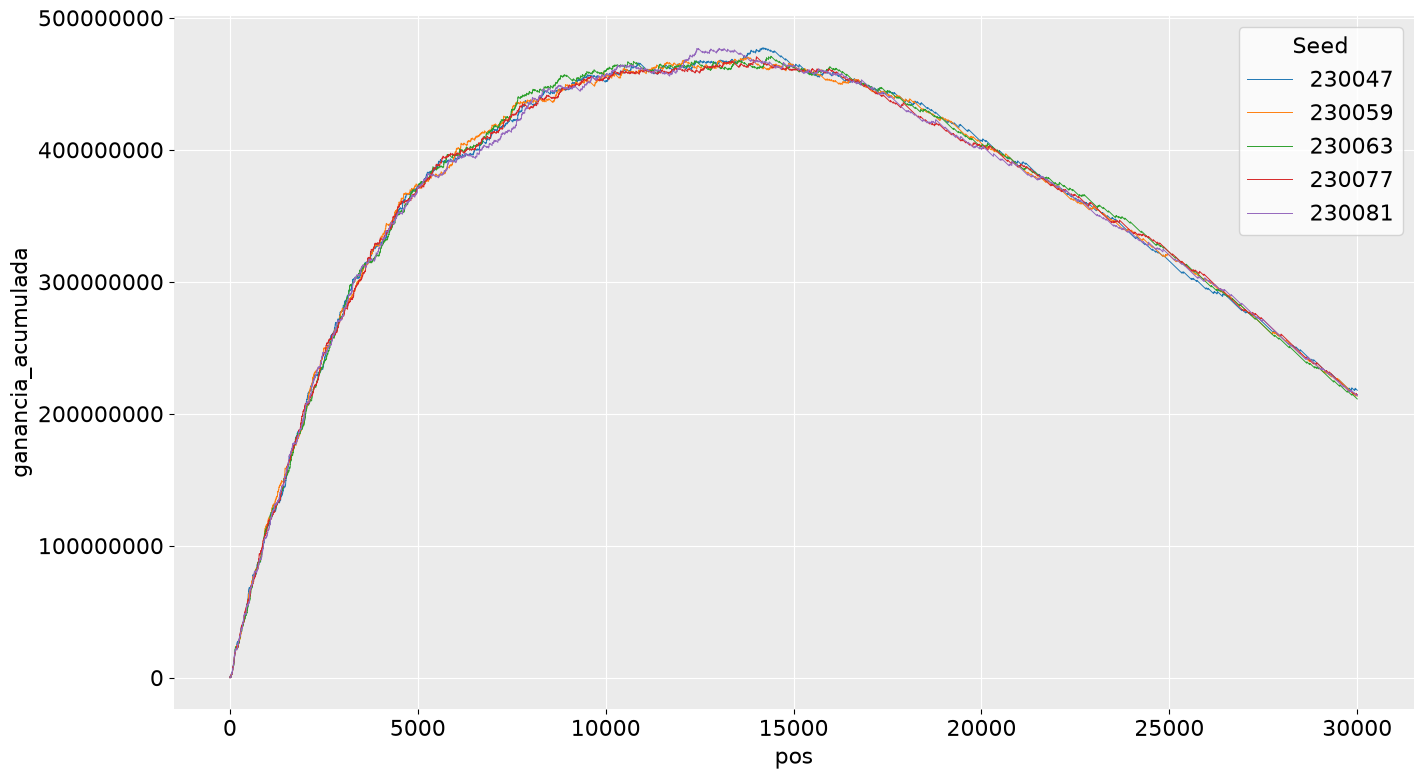

In [22]:
amostrar = 30000
with plt.rc_context({"font.size": 16}):
    fig, ax = plt.subplots(figsize=(16, 9))
    ax.set_facecolor("#EBEBEB")
    ax.set_axisbelow(True)
    ax.grid(True, color="white")
    for seed in SEEDS:
        curva = curvas_semillas[seed]
        curva = curva.loc[curva["pos"] <= amostrar]
        ax.plot(curva["pos"], curva["ganancia_acumulada"], linewidth=0.7, label=str(seed))
    ax.set_xlabel("pos")
    ax.set_ylabel("ganancia_acumulada")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.legend(title="Seed")
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.show()


## Guardar resultados

Una fila por ejecución. `ganancia` es el promedio de las ganancias máximas individuales y `seeds` lista las semillas utilizadas, separadas por comas. Se conservan las demás columnas y el histórico.

Si el CSV existente aún no tiene `seeds`, se incorpora la columna dejando vacías las filas anteriores, sin borrar el histórico. Solo se escribe `validacion_manuales_python.csv`.


In [23]:
existe_archivo = archivo_validaciones.exists()
if existe_archivo:
    validaciones_previas = pd.read_csv(archivo_validaciones)
    id_validacion = int(validaciones_previas["id_validacion"].max()) + 1
else:
    id_validacion = 1

registro_validacion = pd.DataFrame([{
    "id_validacion": id_validacion,
    "ganancia": ganancia_promedio,
    "seeds": ",".join(map(str, SEEDS)),
    "dataset": dataset_file,
    "cantidad_registros_totales": len(dataset),
    "cantidad_registros_entrenamiento": len(dataset_train),
    "cantidad_registros_validacion": len(dfuture),
    "meses_entrenamiento": ",".join(map(str, train_final)),
    "meses_validacion": ",".join(map(str, future)),
    "columnas_excluidas": ",".join(columnas_excluir),
    "benchmark_original": benchmark_base,
}])

carpeta_man_val.mkdir(parents=True, exist_ok=True)
if existe_archivo and "seeds" not in validaciones_previas.columns:
    # Agrega el nuevo encabezado al histórico existente sin perder sus filas.
    validaciones_previas["seeds"] = ""
    pd.concat([validaciones_previas, registro_validacion], ignore_index=True)[
        registro_validacion.columns
    ].to_csv(archivo_validaciones, index=False)
else:
    registro_validacion.to_csv(
        archivo_validaciones,
        mode="a" if existe_archivo else "w",
        header=not existe_archivo,
        index=False,
    )
display(registro_validacion)


,id_validacion,ganancia,seeds,dataset,cantidad_registros_totales,cantidad_registros_entrenamiento,cantidad_registros_validacion,meses_entrenamiento,meses_validacion,columnas_excluidas,benchmark_original
0,5,473192500.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643


## Histórico

In [24]:
historico = pd.read_csv(archivo_validaciones)
display(historico)


,id_validacion,ganancia,seeds,dataset,cantidad_registros_totales,cantidad_registros_entrenamiento,cantidad_registros_validacion,meses_entrenamiento,meses_validacion,columnas_excluidas,benchmark_original
0,1,475227500.0,NaN,competencia_01_ternaria_lags.csv,983061,326184,164114,"202103,202104",202106,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643
1,2,477317500.0,NaN,competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643
2,3,471779000.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lags.csv,983061,326184,164114,"202103,202104",202106,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643
3,4,473192500.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643
4,5,473192500.0,"230047,230059,230063,230077,230081",competencia_01_ternaria_lf_k6_perdida4.csv,983061,326184,164114,"202103,202104",202106,"ternaria,ternaria_lag1,clase01,fold,azar,train...",benchmark_multisemilla_lags20260924_090643
